# Previsione del volume di accessi al Pronto Soccorso con lisciamento esponenziale (PROC ESM)


## Sintesi esecutiva

Un sistema ospedaliero di medie dimensioni ha bisogno di una previsione a un anno del volume mensile di accessi al Pronto Soccorso (PS) per pianificare l'organico infermieristico e la capacità di posti letto in vista dell'ondata respiratoria invernale. Questo notebook costruisce un censimento mensile sintetico del PS su quattro anni (48 mesi, gennaio 2021 - dicembre 2024) e adatta un modello stagionale moltiplicativo di Winters con **PROC ESM** per produrre una previsione a 12 mesi con intervalli di previsione al 95%.

Il modello adattato cattura bene la serie: in campione l'**RMSE è di circa 320 accessi** e il **MAPE è del 4,16%**, quindi l'errore mensile tipico è inferiore al 5% del volume. La previsione proietta la consueta forma stagionale nel 2025 - un picco tra dicembre e febbraio vicino a **7.300-7.800 accessi/mese** e un minimo di fine estate vicino a **5.800-5.900** - con bande di previsione che si allargano man mano che l'orizzonte si estende. Quei numeri, e i pesi di lisciamento che vi stanno dietro, sono letti direttamente dai dataset di output della procedura più sotto.


## Fonti dei dati

| Dataset | Righe | Grana | Variabili chiave | Descrizione |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Una riga per mese di calendario, gen 2021 - dic 2024 | `month` (data SAS mensile), `ed_visits` (conteggio intero mensile degli accessi al PS) | Volume mensile sintetico degli accessi al Pronto Soccorso per un sistema ospedaliero di medie dimensioni. Generato con un trend di crescita al rialzo (~3% annuo), un ciclo stagionale moltiplicativo che culmina nella stagione respiratoria invernale (dic-feb) e cala a fine estate, oltre a rumore log-normale in modo che l'ampiezza stagionale scali con il livello crescente. |


# Previsione del volume di accessi al Pronto Soccorso con PROC ESM

I pianificatori della capacità hanno bisogno di sapere quanti accessi al PS aspettarsi ogni mese per poter programmare gli infermieri, tenere posti letto flessibili e predisporre le forniture respiratorie prima dell'ondata invernale. Il volume del PS è una serie storica stagionale da manuale: cresce lentamente anno dopo anno, culmina durante la stagione respiratoria di dicembre-febbraio e cala a fine estate, e l'entità dell'oscillazione stagionale cresce al crescere del volume di base. Quella struttura stagionale moltiplicativa è esattamente ciò che il metodo moltiplicativo di Winters in **PROC ESM** è progettato per catturare.

In questo notebook:

1. Generiamo un censimento mensile realistico del PS su quattro anni con trend, stagionalità moltiplicativa e rumore.
2. Visualizziamo la serie per confermarne la struttura stagionale moltiplicativa.
3. Adattiamo un modello moltiplicativo di Winters con PROC ESM e leggiamo i suoi pesi di lisciamento e le statistiche di adattamento dai dataset di output.
4. Produciamo una previsione a 12 mesi con intervalli di previsione al 95% e ne interpretiamo le implicazioni operative.


## Passo 1 - Generare il censimento mensile sintetico del PS

Costruiamo 48 osservazioni mensili da gennaio 2021 a dicembre 2024. Il volume atteso di ciascun mese è un livello di base che cresce circa del 3% all'anno, moltiplicato per un indice stagionale (massimo a metà inverno, minimo a fine estate), poi perturbato da rumore log-normale in modo che la variazione casuale scali con il livello. `intnx` avanza la data allineata al mese di un periodo per riga, e `streaminit` rende l'estrazione riproducibile.


In [1]:
DATI ed_census;
    CHIAMARE streaminit(20240531);
    /* Indice stagionale mensile: picco dic-feb (influenza/VRS), minimo ago-set */
    VETTORE seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    FORMATO month yymmn6.;
    FARE i = 1 FINO_A 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Base ~6000 accessi/mese in crescita ~3% all'anno */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Stagionalita moltiplicativa + rumore lognormale scalato sul livello */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        USCITA;
    FINE;
    MANTENERE month ed_visits;
ESEGUIRE;

PROCEDURA STAMPARE DATI=ed_census(obs=14) noobs ETICHETTA;
    ETICHETTA month = 'Mese' ed_visits = 'Accessi al PS';
    TITOLO 'Primi 14 mesi del volume sintetico di accessi al PS';
ESEGUIRE;

                                  Primi 14 mesi del volume sintetico di accessi al PS                                   

  Mese  Accessi al PS
202101           7103
202102           6835
202103           6668
202104           5611
202105           5816
202106           5383
202107           5586
202108           5283
202109           5161
202110           6109
202111           6451
202112           6730
202201           6847
202202           7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


I primi mesi confermano il disegno: il volume apre vicino a 7.100 nel picco di gennaio 2021, scende durante la primavera e l'estate fino al minimo di agosto-settembre, poi risale verso l'inverno successivo. Entro gennaio 2022 il picco è salito a circa 6.800-7.200, riflettendo la crescita annua di ~3% sovrapposta al ciclo stagionale.


## Passo 2 - Visualizzare la serie

Prima di modellare, tracciamo la serie grezza per confermare la struttura che ci aspettiamo: un delicato trend al rialzo con un picco annuale ripetuto ogni inverno la cui ampiezza si allarga nel tempo. Un'oscillazione stagionale crescente è la firma di un processo stagionale *moltiplicativo* e ci dice quale modello ESM scegliere.


                                  Primi 14 mesi del volume sintetico di accessi al PS                                   




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


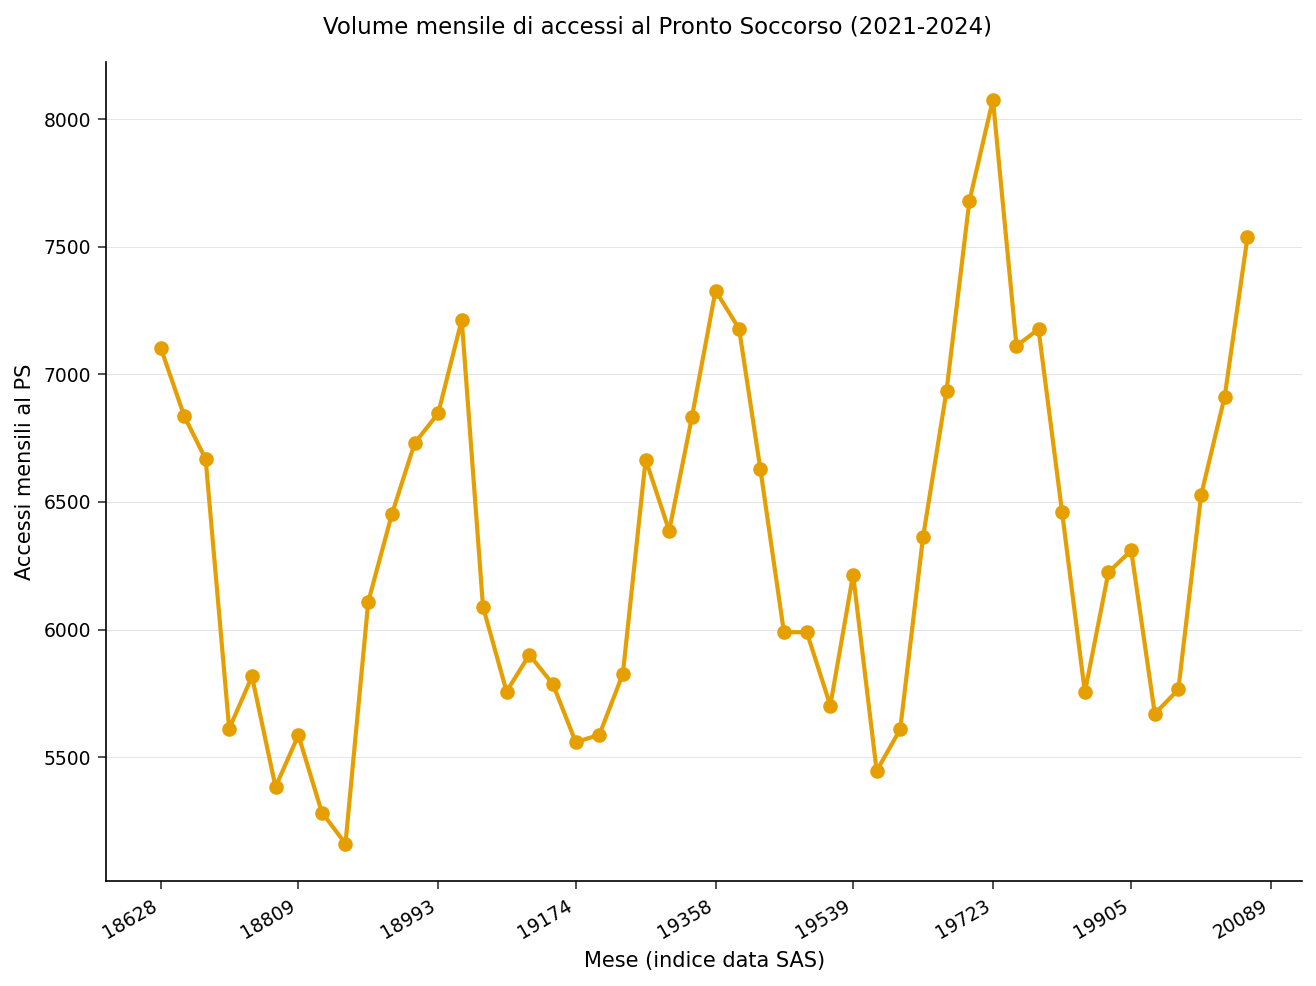

In [2]:
PROCEDURA SGPLOT DATI=ed_census;
    ETICHETTA month='Mese' ed_visits='Accessi al PS';
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS ETICHETTA='Mese (indice data SAS)';
    YAXIS ETICHETTA='Accessi mensili al PS' grid;
    TITOLO 'Volume mensile di accessi al Pronto Soccorso (2021-2024)';
ESEGUIRE;

Il grafico mostra quattro cicli annuali netti. Ogni picco invernale è un po' più alto del precedente, salendo da circa 7.100 nel 2021 a circa 8.100 al picco del 2024, mentre i minimi estivi salgono più modestamente - l'oscillazione stagionale cresce con il livello. Quell'ampiezza crescente è il segno distintivo della stagionalità moltiplicativa e giustifica `MODEL=WINTERS` (Winters moltiplicativo) nel passo successivo.


## Passo 3 - Adattare il modello moltiplicativo di Winters

Adattiamo il lisciamento stagionale moltiplicativo di Winters sull'intera storia di 48 mesi. L'istruzione `ID` dichiara `month` come indice temporale con intervallo `MONTH`, e l'istruzione `FORECAST` richiede `MODEL=WINTERS` con `LEAD=12` per proiettare un anno in avanti. Catturiamo tre dataset di output:

- `OUT=` - la serie storica con la previsione accodata (una colonna `ed_visits`), con l'ID temporale esteso sull'orizzonte di previsione - ideale per il tracciamento.
- `OUTFOR=` - le componenti della previsione per periodo: previsione puntuale (`PREDICT`) e i limiti di previsione inferiore/superiore.
- `OUTSUM=` - le statistiche di adattamento del modello (RMSE, MAE, MAPE, AIC) e i pesi di lisciamento, in una singola riga di riepilogo.

`ALPHA=0.05` produce limiti di previsione al 95%, appropriati per i margini di rischio nella pianificazione della capacità. `PRINT=(STATISTICS)` riporta le statistiche di adattamento e i pesi di lisciamento nel listato.


In [3]:
PROCEDURA esm DATI=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        STAMPARE=(statistics);
    id month interval=month;
    forecast ed_visits / MODELLO=winters ALPHA=0.05;
ESEGUIRE;

PROCEDURA STAMPARE DATI=esm_summary noobs ETICHETTA;
    ETICHETTA rmse='RMSE' mae='MAE' mape='MAPE'
          ALPHA='Livello (alpha)' beta='Trend (beta)' gamma='Stagione (gamma)';
    VARIABILE rmse mae mape ALPHA beta gamma;
    TITOLO 'Statistiche di adattamento di Winters e pesi di lisciamento';
ESEGUIRE;

                                  Primi 14 mesi del volume sintetico di accessi al PS                                   


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                              Statistiche di adattamento di Winters e pesi di lisciamento                               

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


La riga `OUTSUM=` e le statistiche stampate concordano: l'adattamento moltiplicativo di Winters raggiunge in campione un **RMSE di 320,4 accessi**, un **MAE di 264,4** e un **MAPE del 4,16%** - un errore mensile tipico ben al di sotto del 5% del volume, che è comodamente accurato per la pianificazione dell'organico. I pesi di lisciamento sono **alpha = 0,30** (livello), **beta = 0,10** (trend) e **gamma = 0,10** (stagione). Il peso moderato del livello consente alla base di derivare al rialzo con la crescita della popolazione di pazienti, mentre i piccoli pesi di trend e stagione riflettono il fatto che il tasso di crescita e la forma dell'ondata invernale sono stabili di anno in anno e non dovrebbero essere sovra-reagiti di mese in mese.

> Nota: queste sono statistiche di adattamento *in campione* calcolate sul campione di stima, non su un campione di validazione fuori campione. Quantificano quanto strettamente il modello segue la storia su cui è stato adattato.


## Passo 4 - Assemblare e tabulare la previsione a 12 mesi

Il dataset `OUTFOR=` contiene la previsione puntuale e i limiti di previsione per ogni periodo, mentre il dataset `OUT=` porta l'ID temporale esteso in modo pulito sull'orizzonte di previsione. Allineiamo i due per ordine di osservazione per attribuire le date di previsione ai limiti di previsione, poi manteniamo solo i 12 mesi di previsione. Questi sono i numeri su cui agirebbe un comitato per l'organico.


In [4]:
/* OUT= porta le date dell'orizzonte di previsione; OUTFOR= porta i limiti
   di previsione. Allineali per ordine di osservazione per mettere le date
   sui limiti, poi mantieni solo i 12 mesi di previsione.               */
DATI out_idx;
    IMPOSTARE ed_with_forecast;
    row = _n_;
    RINOMINARE month = fdate ed_visits = series_value;
ESEGUIRE;

DATI for_idx;
    IMPOSTARE esm_forecast;
    row = _n_;
    RINOMINARE ed_visits = observed;
    MANTENERE row observed predict LOWER UPPER;
ESEGUIRE;

DATI forecast_path;
    UNIRE out_idx for_idx;
    PER row;
    FORMATO fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
ESEGUIRE;

DATI forecast_horizon;
    IMPOSTARE forecast_path;
    DOVE observed = .;   /* solo i mesi di previsione (nessun valore osservato) */
    MANTENERE fdate predict LOWER UPPER;
ESEGUIRE;

PROCEDURA STAMPARE DATI=forecast_horizon noobs ETICHETTA;
    ETICHETTA fdate   = 'Mese'
          predict = 'Accessi previsti'
          LOWER   = 'Limite inf. 95%'
          UPPER   = 'Limite sup. 95%';
    TITOLO 'Previsione a 12 mesi degli accessi al PS con limiti di previsione al 95%';
ESEGUIRE;

                        Previsione a 12 mesi degli accessi al PS con limiti di previsione al 95%                        

  Mese  Accessi previsti  Limite inf. 95%  Limite sup. 95%
202501             7,822            7,194            8,450
202502             7,539            6,651            8,427
202503             7,292            6,204            8,380
202504             6,263            5,007            7,519
202505             6,397            4,992            7,801
202506             6,039            4,501            7,578
202507             6,236            4,574            7,897
202508             5,867            4,091            7,644
202509             5,802            3,918            7,686
202510             6,804            4,818            8,790
202511             7,173            5,090            9,256
202512             7,567            5,391            9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


La previsione porta la firma stagionale in avanti nel 2025. Il modello proietta il picco di gennaio 2025 a circa **7.822 accessi** (intervallo al 95% 7.194-8.450), si attenua durante la primavera, tocca il fondo nel minimo di fine estate vicino a **5.802** a settembre (intervallo 3.918-7.686), poi risale a un picco di dicembre di circa **7.567** (intervallo 5.391-9.742). La banda di previsione si allarga costantemente con l'orizzonte - l'intervallo del mese prossimo copre circa +/-630 accessi, mentre quello del prossimo dicembre copre più di +/-2.000 - un promemoria diretto che i piani a breve termine sono molto più solidi di quelli di fine anno.


## Passo 5 - Tracciare storia più previsione

Infine, sovrapponiamo la previsione alla storia osservata in modo che i pianificatori possano vedere il picco invernale proiettato e la banda di incertezza crescente man mano che l'orizzonte si estende. Suddividiamo la serie allineata `forecast_path` nella storia **osservata** (linea continua) e nella **previsione a 12 mesi** (linea tratteggiata) in modo che il passaggio sia chiaro, e disegniamo sotto la banda di previsione al 95%. L'asse x è l'indice della data SAS mensile, che va da sinistra a destra da gennaio 2021 a dicembre 2025.


                        Previsione a 12 mesi degli accessi al PS con limiti di previsione al 95%                        




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


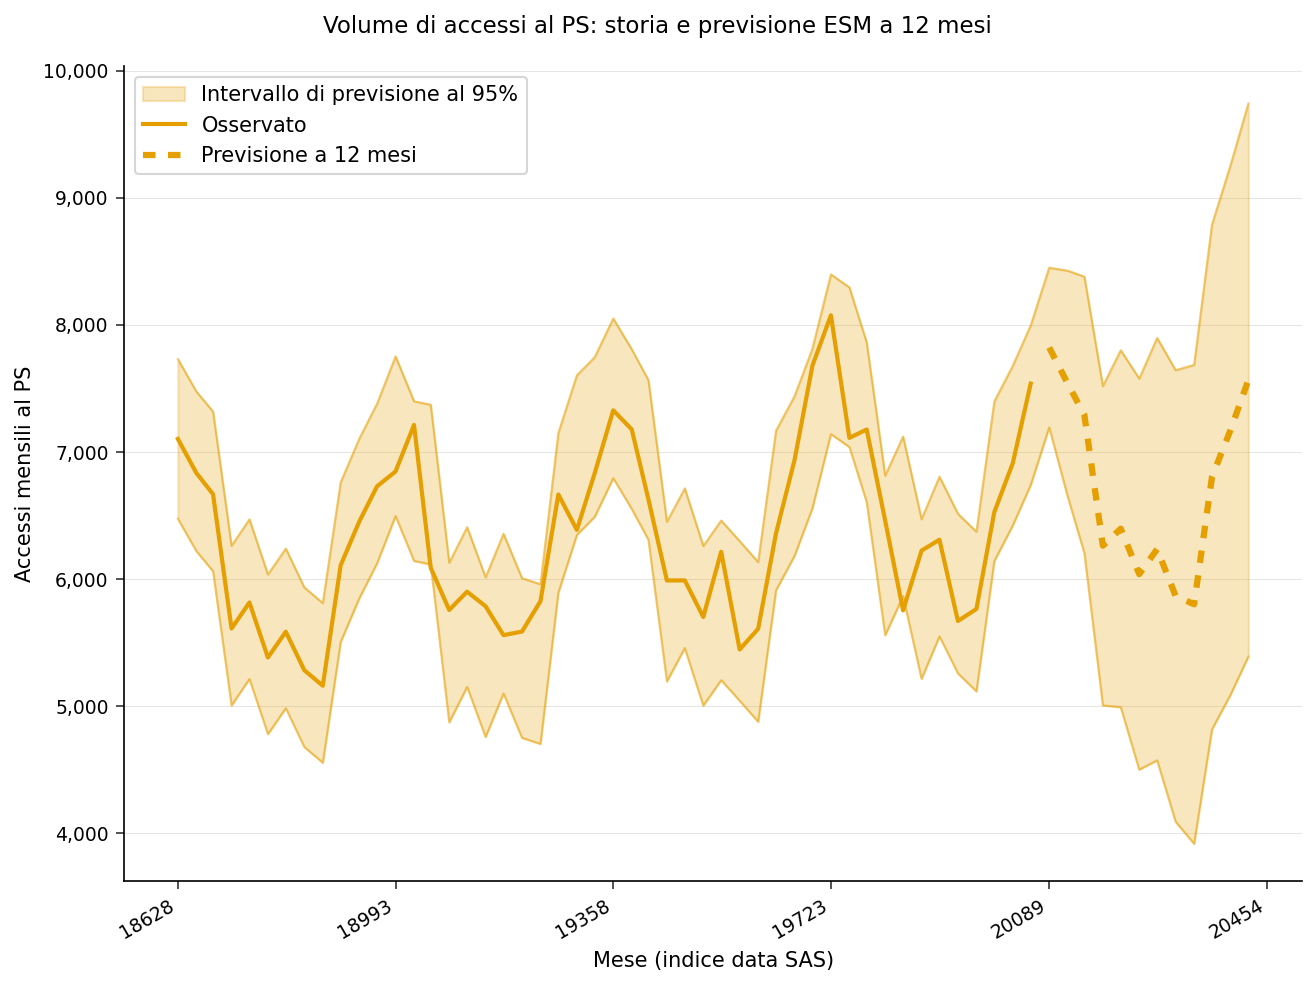

In [5]:
/* Suddividi la serie proiettata nella storia osservata e nella previsione a
   12 mesi cosi da renderle con stili distinti, e sovrapponi la banda di
   previsione al 95% dal dataset allineato forecast_path.                */
DATI forecast_plot;
    IMPOSTARE forecast_path;
    SE_COND observed = . ALLORA fc_only = predict;   /* solo i mesi futuri */
    ALTRIMENTI fc_only = .;
ESEGUIRE;

PROCEDURA SGPLOT DATI=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel='Intervallo di previsione al 95%' TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel='Osservato';
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel='Previsione a 12 mesi';
    XAXIS ETICHETTA='Mese (indice data SAS)';
    YAXIS ETICHETTA='Accessi mensili al PS' grid;
    TITOLO 'Volume di accessi al PS: storia e previsione ESM a 12 mesi';
ESEGUIRE;

## Interpretare i risultati

Il modello moltiplicativo di Winters scompone il volume del PS in un **livello** che sale lentamente, un **trend** quasi piatto e un **pattern stagionale** stabile. I pesi di lisciamento letti da `OUTSUM=` raccontano la storia: un peso moderato del livello (alpha = 0,30) consente alla base di derivare al rialzo con la crescita della popolazione di pazienti, mentre piccoli pesi di trend e stagione (beta = gamma = 0,10) riflettono il fatto che il tasso di crescita e la forma dell'ondata invernale sono molto stabili di anno in anno e non dovrebbero essere sovra-reagiti di mese in mese.

Le **statistiche di adattamento** confermano che il modello segue bene la storia: un RMSE di circa 320 accessi e un MAPE del 4,16% significano che l'errore mensile tipico è inferiore al 5% del volume. Operativamente, la **tabella di previsione e il grafico a bande** quantificano il picco di dicembre-febbraio verso cui il PS dovrebbe dimensionare l'organico - circa 7.300-7.800 accessi nei mesi invernali - e i limiti di previsione al 95% definiscono un intervallo di capacità prudente: pianificare l'organico di base sulla previsione puntuale, e predisporre copertura flessibile e posti letto per l'ondata verso il limite superiore. L'intervallo si allarga con l'orizzonte, quindi il piano del mese prossimo è molto più solido di quello del prossimo dicembre e dovrebbe essere aggiornato man mano che arrivano nuovi dati effettivi.

**Estensioni:** confrontare `MODEL=ADDWINTERS` (stagionalità additiva) con l'adattamento moltiplicativo per confermare la scelta moltiplicativa; applicare `TRANSFORM=LOG` per imporre la positività e stabilizzare la varianza; oppure aggiungere un'istruzione `BY` per prevedere più sedi ospedaliere in un'unica chiamata a PROC ESM.
